# Thesis Figures
Generates all figures for the Proposed Solution chapter.
All outputs go to `generated/thesis_figures/`.
Model-dependent cells (alignment, sentences) are at the bottom — run config + imports first.

In [33]:
# Paths
DATASET_ROOT   = '/extra_space2/oles_new/UkrHandwritten_Words_CC'
META_BALANCED  = DATASET_ROOT + '/METAFILE_extended_balanced.tsv'
META_CLEAN     = DATASET_ROOT + '/METAFILE_clean.tsv'
LINES_DIR      = '/extra_space2/oles_new/UkrHandwritten/lines/lines'
LINES_META     = '/extra_space2/oles_new/UkrHandwritten/METAFILE.tsv'
CKPT_PATH      = '/home/oles/DiffusionPen/output/diffusionpen_ukr_v9/models/ckpt.pt'
STYLE_CKPT     = '/home/oles/DiffusionPen/style_models/ukr_mixed_wt0p7/mixed_ukr_mobilenetv2_100.pth'
SD_PATH        = '/home/oles/DiffusionPen/stable-diffusion-v1-5'
OUT_DIR        = '/home/oles/DiffusionPen/generated/thesis_figures'

TB_DIRS = {
    'v7': '/home/oles/DiffusionPen/output/diffusionpen_ukr_v7/tensorboard/ukr_diffusionpen_1773662399',
    'v8': '/home/oles/DiffusionPen/output/diffusionpen_ukr_v8/tensorboard/ukr_diffusionpen_1774280492',
    'v9': '/home/oles/DiffusionPen/output/diffusionpen_ukr_v9/tensorboard/ukr_diffusionpen_1775149857',
}

# CC segmentation demo — pick any line filename from LINES_DIR
CC_DEMO_LINE   = 'a01-001-0023-03.png'   # change to any line with 4-6 words

# Writer IDs (string, 4-digit) for sentence generation
# Pick 3 visually distinct writers from the 323 available
SENTENCE_WRITERS = ['0004', '0050', '0120']

# Text to generate for the sentence strip figure
SENTENCE_TEXT            = 'думи мої думи'
SENTENCE_TEXT_HYPHENATED = 'жовто-блакитний прапор'

# Words to generate for the alignment figure
ALIGNMENT_WORDS = ['думи', 'мої', 'прапор', 'річка', 'серце']
ALIGNMENT_WRITER = '0004'    # writer used for both rows

# Model
DEVICE         = 'cuda:0'
NUM_RES_BLOCKS = 2
CFG_SCALE      = 5.0
IMG_H, IMG_W   = 64, 256

import os
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: /home/oles/DiffusionPen/generated/thesis_figures


In [34]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import sys, csv, collections, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as mpl_patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import cv2
from PIL import Image

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'figure.dpi': 150,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
})

sys.path.insert(0, '/home/oles/DiffusionPen')
print('imports ok')

imports ok


---
## Fig 1 — CC Gap Detection Schematic

Line: "паломниками, чи екскурсійно-"  →  3 words


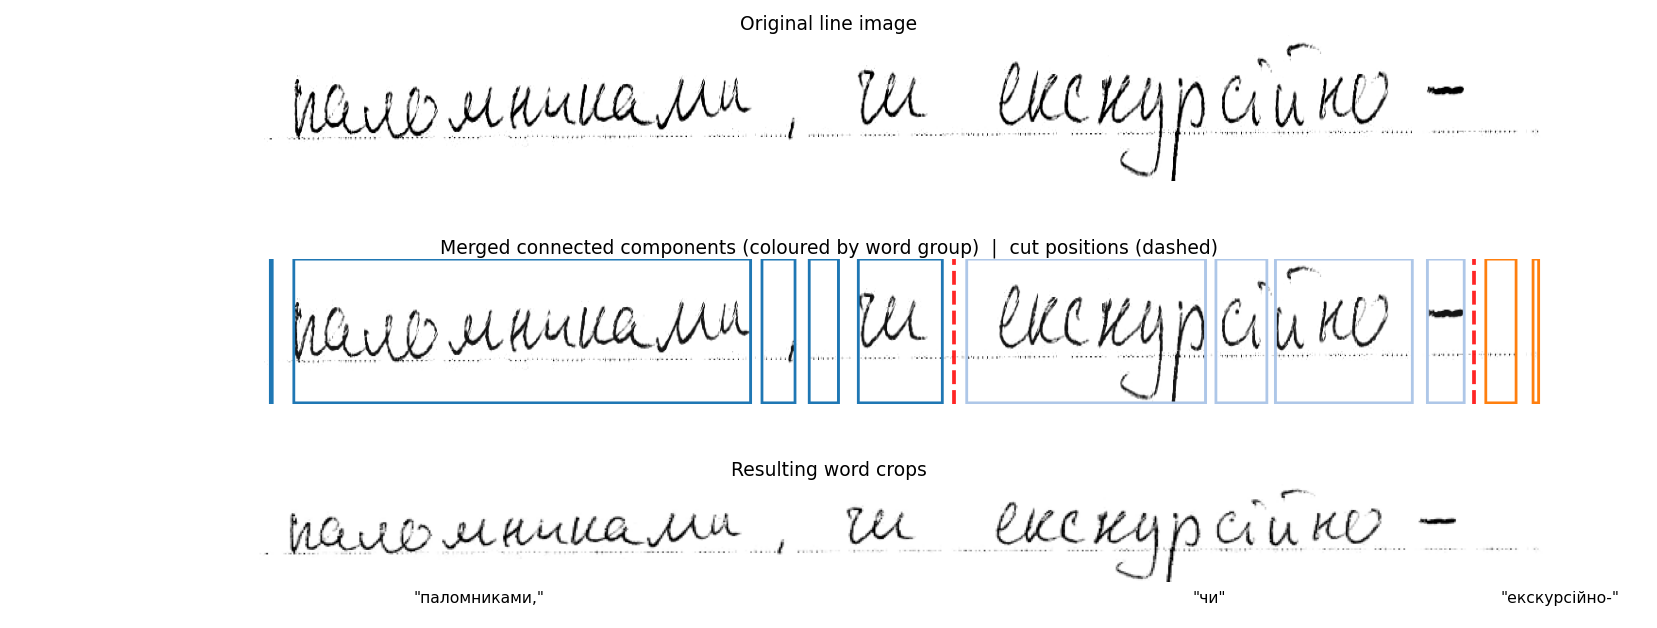

saved /home/oles/DiffusionPen/generated/thesis_figures/fig1_cc_segmentation.pdf


In [35]:
def cc_segment(img_gray, n_words, merge_dist=8):
    """Return list of (x_left, x_right) word boundaries."""
    _, bw = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)

    # collect (x_left, x_right) per non-background component, sorted by x
    boxes = []
    for i in range(1, n_labels):
        x  = stats[i, cv2.CC_STAT_LEFT]
        w  = stats[i, cv2.CC_STAT_WIDTH]
        boxes.append([x, x + w])
    boxes.sort(key=lambda b: b[0])

    # merge blobs within merge_dist pixels
    merged = []
    for b in boxes:
        if merged and b[0] - merged[-1][1] <= merge_dist:
            merged[-1][1] = max(merged[-1][1], b[1])
        else:
            merged.append(list(b))

    # pick n_words-1 widest gaps
    gaps = []
    for i in range(len(merged) - 1):
        gap_x  = merged[i][1]
        gap_w  = merged[i+1][0] - merged[i][1]
        gaps.append((gap_w, gap_x, i))
    gaps.sort(reverse=True)
    cut_positions = sorted([g[1] + (merged[g[2]+1][0] - merged[g[2]][1]) // 2
                            for g in gaps[:n_words - 1]])

    # build word boundary pairs
    boundaries = []
    prev = 0
    for cp in cut_positions:
        boundaries.append((prev, cp))
        prev = cp
    boundaries.append((prev, img_gray.shape[1]))
    return merged, cut_positions, boundaries


# Load line image
line_path = os.path.join(LINES_DIR, CC_DEMO_LINE)
line_bgr  = cv2.imread(line_path)
line_gray = cv2.cvtColor(line_bgr, cv2.COLOR_BGR2GRAY)

# Find word count from metafile
n_words = None
with open(LINES_META, 'r', encoding='utf-8') as f:
    for row in csv.reader(f, delimiter='\t'):
        if row and row[0] == CC_DEMO_LINE:
            n_words = len(row[1].split())
            gt_text = row[1]
            break
assert n_words, f'Line {CC_DEMO_LINE} not found in metafile'
print(f'Line: "{gt_text}"  →  {n_words} words')

merged_boxes, cut_xs, boundaries = cc_segment(line_gray, n_words)

COLORS = plt.cm.tab20.colors

H, W = line_gray.shape
crop_h = 64   # display height for word crops row

fig, axes = plt.subplots(3, 1, figsize=(14, 5),
                         gridspec_kw={'height_ratios': [1, 1, 0.9], 'hspace': 0.55})

# Row 0 — original line
axes[0].imshow(line_gray, cmap='gray', aspect='auto')
axes[0].set_title('Original line image', fontsize=9, pad=3)
axes[0].axis('off')

# Row 1 — merged CCs with colored bounding boxes + cut lines
line_rgb = cv2.cvtColor(line_gray, cv2.COLOR_GRAY2RGB)
word_color_idx = 0
# assign each merged box to a word group based on cut positions
def word_group(xc):
    for i, cp in enumerate(cut_xs):
        if xc < cp:
            return i
    return len(cut_xs)

overlay = line_rgb.copy()
for box in merged_boxes:
    xL, xR = box
    xC = (xL + xR) // 2
    g  = word_group(xC)
    c  = [int(v * 255) for v in COLORS[g % len(COLORS)][:3]]
    cv2.rectangle(overlay, (xL, 0), (xR, H-1), c, 2)

axes[1].imshow(overlay, aspect='auto')
for cx in cut_xs:
    axes[1].axvline(x=cx, color='red', linewidth=1.8, linestyle='--', alpha=0.85)
axes[1].set_title('Merged connected components (coloured by word group)  |  cut positions (dashed)',
                   fontsize=9, pad=3)
axes[1].axis('off')

# Row 2 — word crops side by side
crop_imgs = []
gt_words  = gt_text.split()
for i, (xl, xr) in enumerate(boundaries):
    crop = line_gray[:, xl:xr]
    scale = crop_h / crop.shape[0]
    new_w = max(1, int(crop.shape[1] * scale))
    crop_rs = cv2.resize(crop, (new_w, crop_h))
    crop_imgs.append((crop_rs, gt_words[i] if i < len(gt_words) else ''))

# build a single strip with 6 px white gaps
gap = np.full((crop_h, 6), 255, dtype=np.uint8)
strip_parts = []
for ci, (cimg, _) in enumerate(crop_imgs):
    if ci > 0:
        strip_parts.append(gap)
    strip_parts.append(cimg)
strip = np.concatenate(strip_parts, axis=1)

axes[2].imshow(strip, cmap='gray', aspect='auto')
# draw vertical separators and word labels
x_cursor = 0
for ci, (cimg, lbl) in enumerate(crop_imgs):
    cw = cimg.shape[1]
    cx = x_cursor + cw / 2
    axes[2].text(cx, crop_h + 5, f'"{lbl}"', ha='center', va='top', fontsize=7.5)
    x_cursor += cw + 6
axes[2].set_xlim(0, strip.shape[1])
axes[2].set_ylim(crop_h + 20, -2)
axes[2].set_title('Resulting word crops', fontsize=9, pad=3)
axes[2].axis('off')

out_path = os.path.join(OUT_DIR, 'fig1_cc_segmentation.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

---
## Fig 2 — Filtering Pipeline Flowchart

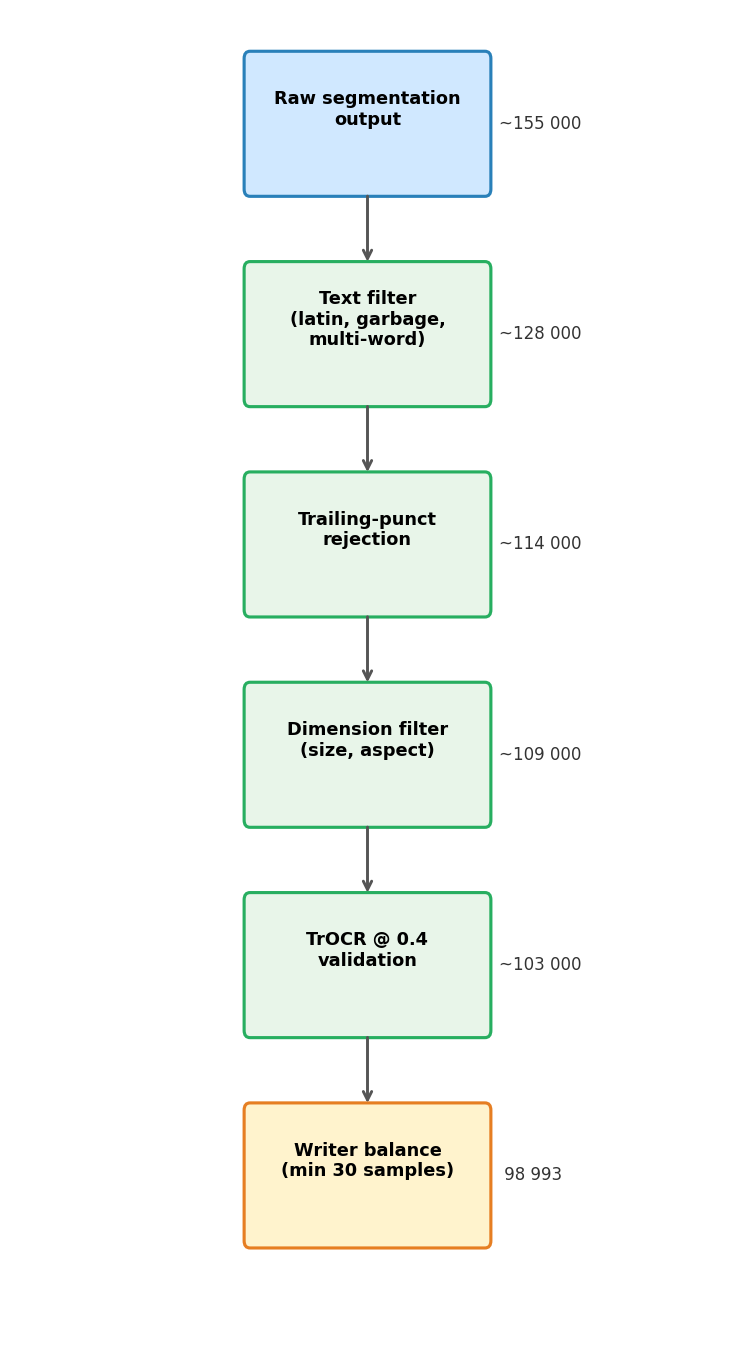

saved /home/oles/DiffusionPen/generated/thesis_figures/fig2_filtering_pipeline.pdf


In [36]:
STAGES = [
    ('Raw segmentation\noutput',           '~155 000'),
    ('Text filter\n(latin, garbage,\nmulti-word)',  '~128 000'),
    ('Trailing-punct\nrejection',          '~114 000'),
    ('Dimension filter\n(size, aspect)',   '~109 000'),
    ('TrOCR @ 0.4\nvalidation',            '~103 000'),
    ('Writer balance\n(min 30 samples)',   ' 98 993'),
]

BOX_W, BOX_H = 2.0, 0.90
GAP_Y        = 0.55   # vertical gap between boxes
X_CENTER     = 0.0
ARROW_LEN    = GAP_Y - 0.04

fig, ax = plt.subplots(figsize=(5, len(STAGES) * (BOX_H + GAP_Y) + 0.4))
ax.set_xlim(-3, 3)
ax.set_ylim(-0.3, len(STAGES) * (BOX_H + GAP_Y) + 0.1)
ax.axis('off')
ax.invert_yaxis()

box_colors = ['#d0e8ff'] + ['#e8f5e9'] * (len(STAGES) - 2) + ['#fff3cd']
edge_colors = ['#2980b9'] + ['#27ae60'] * (len(STAGES) - 2) + ['#e67e22']

y_positions = []
for i, (label, count) in enumerate(STAGES):
    y_top = i * (BOX_H + GAP_Y)
    y_mid = y_top + BOX_H / 2
    y_positions.append((y_top, y_mid))

    box = FancyBboxPatch(
        (X_CENTER - BOX_W / 2, y_top), BOX_W, BOX_H,
        boxstyle='round,pad=0.05',
        facecolor=box_colors[i], edgecolor=edge_colors[i], linewidth=1.5,
    )
    ax.add_patch(box)
    ax.text(X_CENTER, y_mid - 0.10, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', multialignment='center')
    ax.text(X_CENTER + BOX_W / 2 + 0.12, y_mid, count,
            ha='left', va='center', fontsize=8, color='#333333')

    # arrow down to next box
    if i < len(STAGES) - 1:
        y_arrow_start = y_top + BOX_H + 0.02
        y_arrow_end   = y_arrow_start + ARROW_LEN
        ax.annotate('', xy=(X_CENTER, y_arrow_end), xytext=(X_CENTER, y_arrow_start),
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=1.4))

fig.tight_layout()
out_path = os.path.join(OUT_DIR, 'fig2_filtering_pipeline.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

---
## Fig 3 — Letter Frequency Chart (pre/post oversampling)

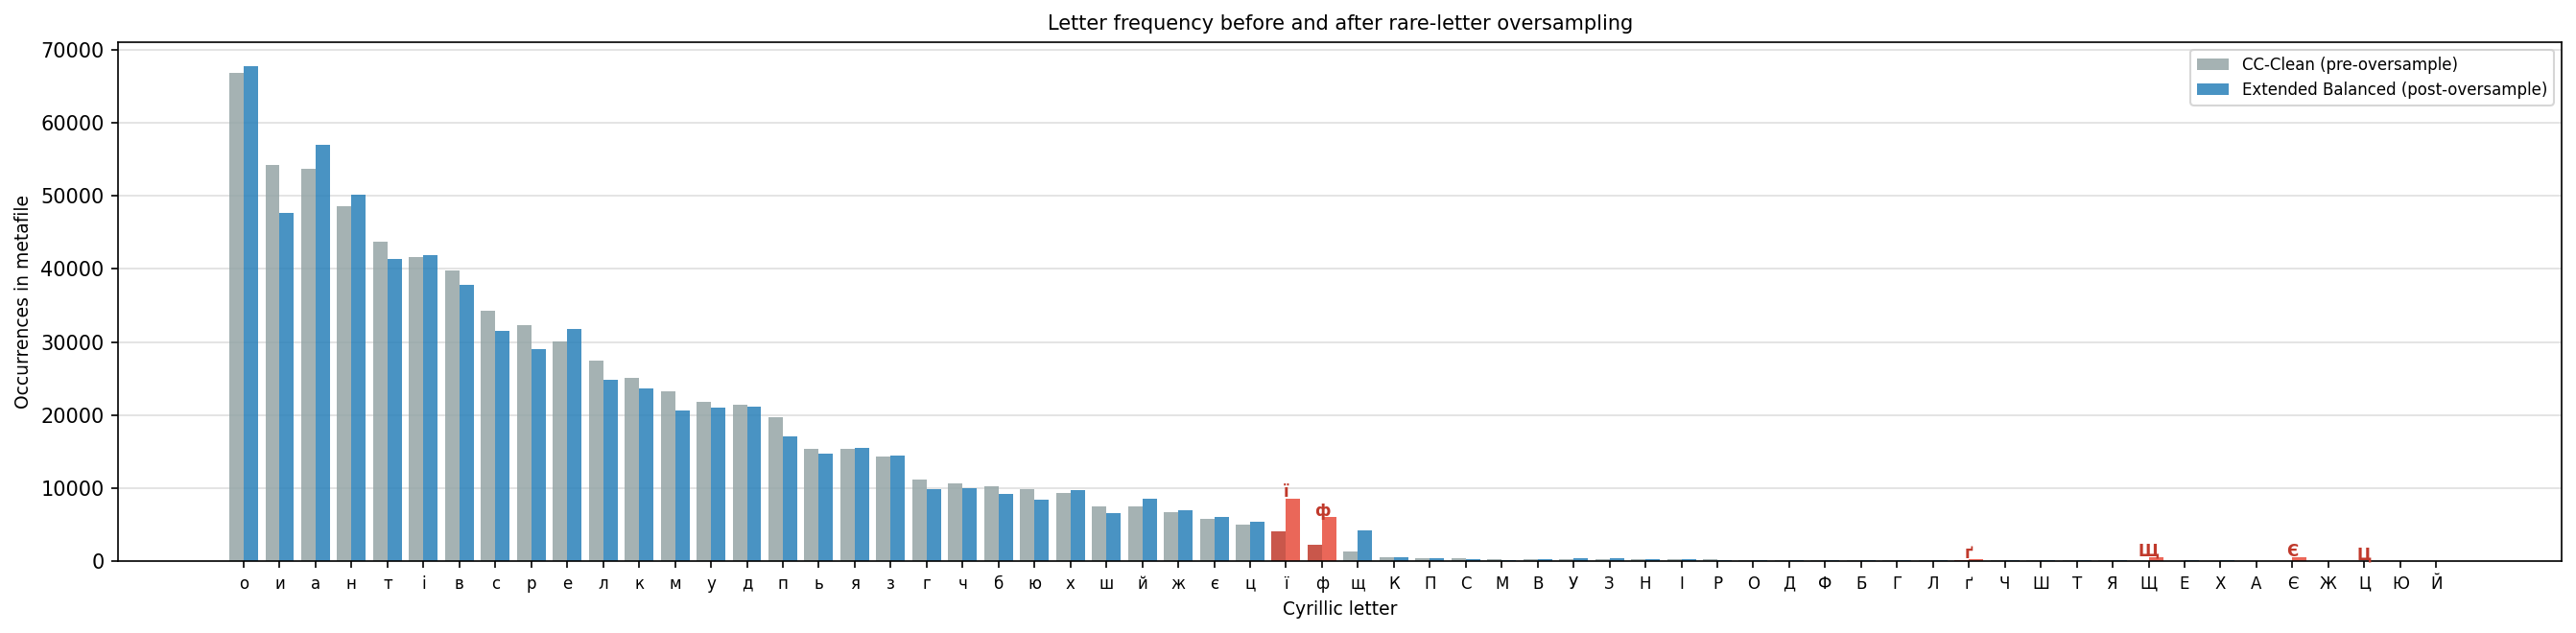

saved /home/oles/DiffusionPen/generated/thesis_figures/fig3_letter_frequency.pdf


In [37]:
# ── LETTER FREQUENCY ─────────────────────────────────────────────────────────
# Reads both metafiles, counts Cyrillic letters, plots grouped bars.

RARE_LETTERS = {'ф', 'Щ', 'Є', 'Ц', 'ґ', 'ї'}

def count_letters(meta_path):
    counts = collections.Counter()
    with open(meta_path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter='\t')
        next(reader, None)  # skip header if present
        for row in reader:
            if len(row) < 2:
                continue
            for ch in row[1]:
                if '\u0400' <= ch <= '\u04ff':  # Cyrillic block
                    counts[ch] += 1
    return counts

pre  = count_letters(META_CLEAN)
post = count_letters(META_BALANCED)

# Union of all letters, sorted by pre-oversample frequency descending
all_letters = sorted(set(pre) | set(post), key=lambda l: -pre.get(l, 0))

pre_vals  = [pre.get(l, 0)  for l in all_letters]
post_vals = [post.get(l, 0) for l in all_letters]

x = np.arange(len(all_letters))
bar_w = 0.4

fig, ax = plt.subplots(figsize=(18, 4.5))

colors_pre  = ['#c0392b' if l in RARE_LETTERS else '#95a5a6' for l in all_letters]
colors_post = ['#e74c3c' if l in RARE_LETTERS else '#2980b9' for l in all_letters]

ax.bar(x - bar_w/2, pre_vals,  bar_w, label='CC-Clean (pre-oversample)',  color=colors_pre,  alpha=0.85)
ax.bar(x + bar_w/2, post_vals, bar_w, label='Extended Balanced (post-oversample)', color=colors_post, alpha=0.85)

# annotate rare letters
for i, l in enumerate(all_letters):
    if l in RARE_LETTERS:
        ax.annotate(l, xy=(i, post_vals[i] + 200), ha='center', fontsize=8,
                    color='#c0392b', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_letters, fontsize=8)
ax.set_ylabel('Occurrences in metafile', fontsize=9)
ax.set_xlabel('Cyrillic letter', fontsize=9)
ax.set_title('Letter frequency before and after rare-letter oversampling', fontsize=10)
ax.legend(fontsize=8)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
out_path = os.path.join(OUT_DIR, 'fig3_letter_frequency.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

---
## Fig 4 — Word Length Histogram

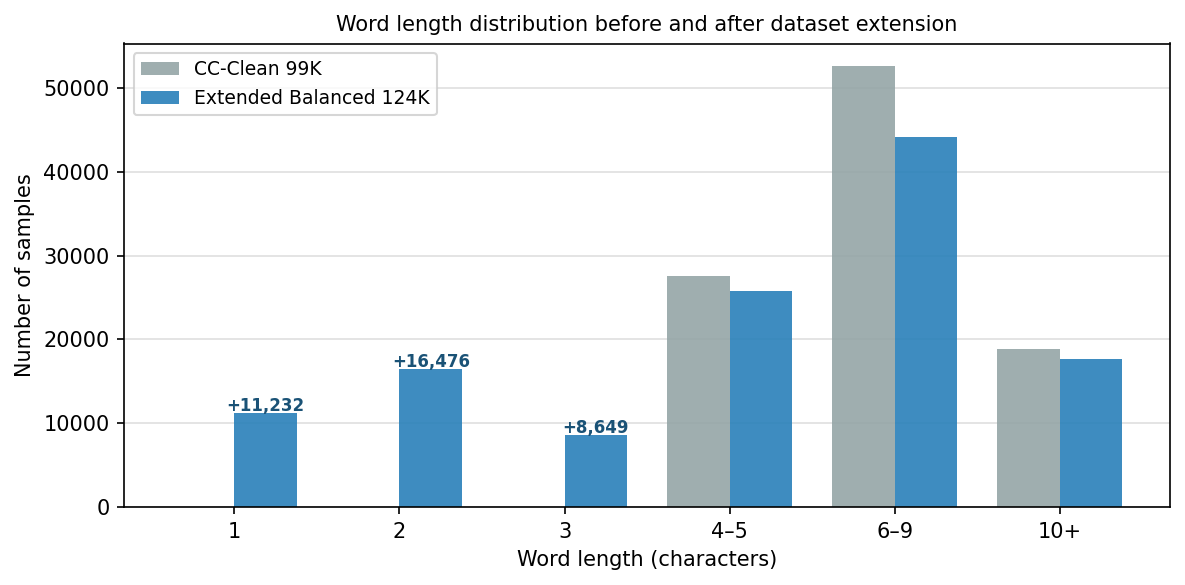

saved /home/oles/DiffusionPen/generated/thesis_figures/fig4_word_length_hist.pdf


In [38]:
# ── WORD LENGTH HISTOGRAM ─────────────────────────────────────────────────────
# Overlays CC-Clean (pre) vs Extended Balanced (post) to show short-word gap fix.

BUCKETS = [(1,1,'1'), (2,2,'2'), (3,3,'3'), (4,5,'4–5'), (6,9,'6–9'), (10,99,'10+')]

def bucket_lengths(meta_path):
    counts = collections.Counter()
    with open(meta_path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter='\t')
        next(reader, None)
        for row in reader:
            if len(row) < 2:
                continue
            n = len(row[1].strip())
            for lo, hi, label in BUCKETS:
                if lo <= n <= hi:
                    counts[label] += 1
                    break
    return [counts[label] for _, _, label in BUCKETS]

labels  = [b[2] for b in BUCKETS]
pre_c   = bucket_lengths(META_CLEAN)
post_c  = bucket_lengths(META_BALANCED)
x       = np.arange(len(labels))
bar_w   = 0.38

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - bar_w/2, pre_c,  bar_w, label='CC-Clean 99K',            color='#95a5a6', alpha=0.9)
ax.bar(x + bar_w/2, post_c, bar_w, label='Extended Balanced 124K',  color='#2980b9', alpha=0.9)

# annotate short-word buckets (1, 2, 3) where the difference is most striking
for i in range(3):
    ax.annotate(f'+{post_c[i]-pre_c[i]:,}',
                xy=(x[i] + bar_w/2, post_c[i] + 200),
                ha='center', fontsize=8, color='#1a5276', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_xlabel('Word length (characters)', fontsize=10)
ax.set_ylabel('Number of samples', fontsize=10)
ax.set_title('Word length distribution before and after dataset extension', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
out_path = os.path.join(OUT_DIR, 'fig4_word_length_hist.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

---
## Fig 5 — Architecture Diagram

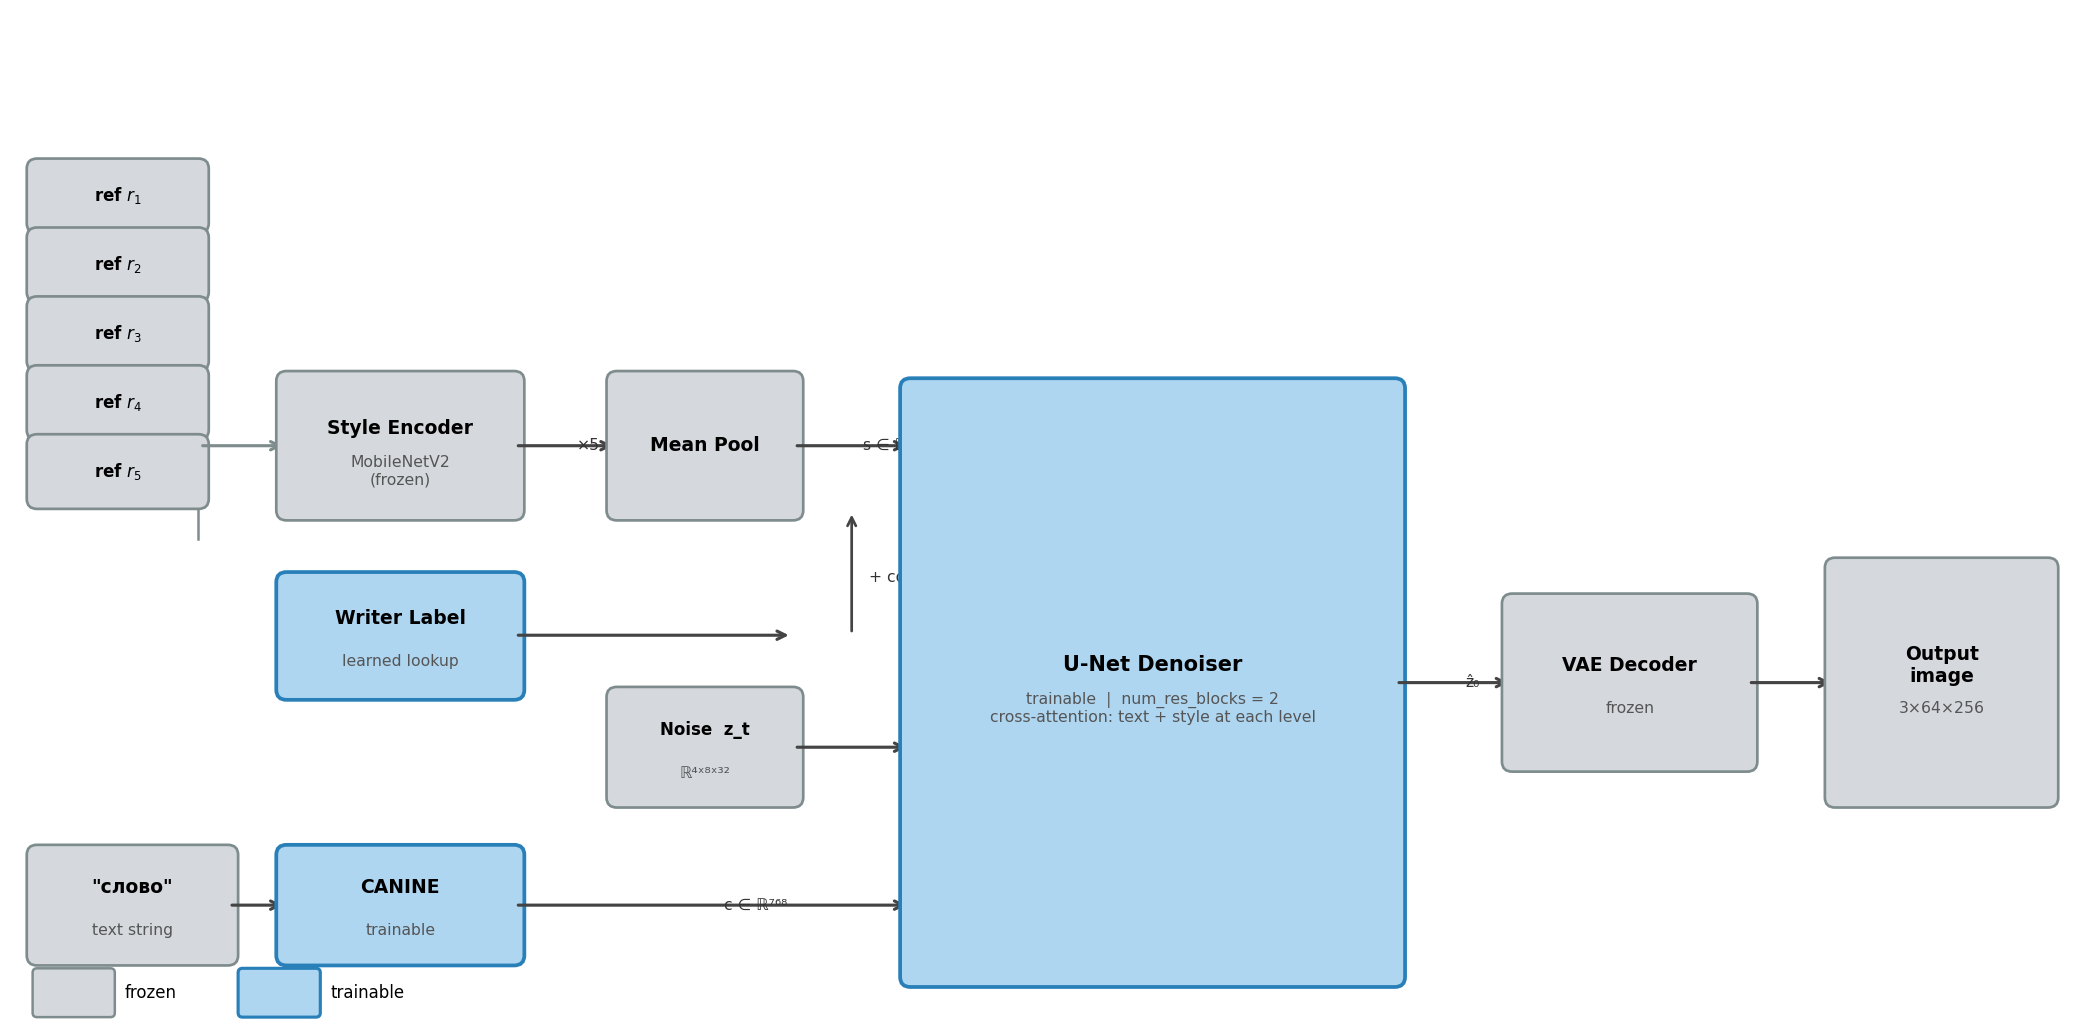

saved /home/oles/DiffusionPen/generated/thesis_figures/fig5_architecture.pdf


In [39]:
# ── ARCHITECTURE DIAGRAM ──────────────────────────────────────────────────────
# Pure matplotlib. No model loading needed.
# Layout: left lane (style), right lane (text), centre (U-Net), right-most (VAE out).

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')

# Colours
FROZEN    = '#d5d8dc'   # grey — frozen
TRAINABLE = '#aed6f1'   # blue — trainable
EDGE_F    = '#7f8c8d'
EDGE_T    = '#2980b9'
ARROW_KW  = dict(arrowstyle='->', color='#444', lw=1.5,
                 connectionstyle='arc3,rad=0.0')

def box(ax, x, y, w, h, label, sublabel='', frozen=True, fontsize=9):
    fc = FROZEN if frozen else TRAINABLE
    ec = EDGE_F if frozen else EDGE_T
    lw = 1.3 if frozen else 1.8
    p  = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.07',
                         facecolor=fc, edgecolor=ec, linewidth=lw, zorder=3)
    ax.add_patch(p)
    cy = y + h/2 + (0.12 if sublabel else 0)
    ax.text(x + w/2, cy, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', zorder=4)
    if sublabel:
        ax.text(x + w/2, cy - 0.30, sublabel, ha='center', va='center',
                fontsize=7.5, color='#555', zorder=4)

def arrow(ax, x0, y0, x1, y1, label='', color='#444'):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx + 0.08, my, label, fontsize=7.5, color='#333', va='center')

# ── Left lane: reference images → style encoder → mean pool ──────────────────
# 5 small ref image boxes
for i in range(5):
    box(ax, 0.15, 5.55 - i*0.48, 1.1, 0.38, f'ref $r_{i+1}$', frozen=True, fontsize=8)

# bracket-style arrow from all 5 refs to style encoder
ax.annotate('', xy=(1.85, 4.0), xytext=(1.25, 4.0),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))
ax.plot([1.25, 1.25], [3.35, 5.55+0.19], color='#7f8c8d', lw=1.2)  # vertical bar
ax.plot([1.25, 1.25+0.0], [3.35, 3.35],  color='#7f8c8d', lw=1.2)

box(ax, 1.85, 3.55, 1.55, 0.90, 'Style Encoder', 'MobileNetV2\n(frozen)', frozen=True)
arrow(ax, 3.40, 4.00, 4.10, 4.00, label='×5')
box(ax, 4.10, 3.55, 1.20, 0.90, 'Mean Pool', frozen=True)
arrow(ax, 5.30, 4.00, 6.10, 4.00, label='s ∈ ℝ¹²⁸⁰')

# writer label
box(ax, 1.85, 2.30, 1.55, 0.75, 'Writer Label', 'learned lookup', frozen=False)
arrow(ax, 3.40, 2.68, 5.30, 2.68)
ax.annotate('', xy=(5.70, 3.55), xytext=(5.70, 2.68),
            arrowprops=dict(arrowstyle='->', color='#444', lw=1.3))
ax.text(5.82, 3.05, '+ concat', fontsize=7.5, color='#333')

# ── Top lane: text string → CANINE ───────────────────────────────────────────
box(ax, 0.15, 0.45, 1.30, 0.70, '"слово"', 'text string', frozen=True, fontsize=9)
arrow(ax, 1.45, 0.80, 1.85, 0.80)
box(ax, 1.85, 0.45, 1.55, 0.70, 'CANINE', 'trainable', frozen=False)
arrow(ax, 3.40, 0.80, 6.10, 0.80, label='c ∈ ℝ⁷⁶⁸')

# ── Noise input ───────────────────────────────────────────────────────────────
box(ax, 4.10, 1.55, 1.20, 0.70, 'Noise  z_t', 'ℝ⁴ˣ⁸ˣ³²', frozen=True, fontsize=8)
arrow(ax, 5.30, 1.90, 6.10, 1.90)

# ── U-Net (centre) ────────────────────────────────────────────────────────────
box(ax, 6.10, 0.30, 3.30, 4.10, 'U-Net Denoiser',
    'trainable  |  num_res_blocks = 2\ncross-attention: text + style at each level',
    frozen=False, fontsize=10)

# arrows from text & style into U-Net
ax.annotate('', xy=(6.10, 0.80), xytext=(3.40+2.70, 0.80),
            arrowprops=dict(arrowstyle='->', color=EDGE_T, lw=1.5))  # text
ax.annotate('', xy=(6.10, 3.70), xytext=(5.30+0.80, 3.70),
            arrowprops=dict(arrowstyle='->', color=EDGE_T, lw=1.5))  # style

# ── VAE decoder ───────────────────────────────────────────────────────────────
arrow(ax, 9.40, 2.35, 10.20, 2.35, label='ẑ₀')
box(ax, 10.20, 1.80, 1.60, 1.10, 'VAE Decoder', 'frozen', frozen=True)
arrow(ax, 11.80, 2.35, 12.40, 2.35)
box(ax, 12.40, 1.55, 1.45, 1.60, 'Output\nimage', '3×64×256', frozen=True, fontsize=9)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch((0.15, 0.05), 0.5, 0.28, boxstyle='round,pad=0.03',
                             facecolor=FROZEN, edgecolor=EDGE_F, linewidth=1.2))
ax.text(0.75, 0.19, 'frozen', fontsize=8, va='center')
ax.add_patch(FancyBboxPatch((1.55, 0.05), 0.5, 0.28, boxstyle='round,pad=0.03',
                             facecolor=TRAINABLE, edgecolor=EDGE_T, linewidth=1.5))
ax.text(2.15, 0.19, 'trainable', fontsize=8, va='center')

fig.tight_layout()
out_path = os.path.join(OUT_DIR, 'fig5_architecture.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

---
## Fig 7 — Validation MSE Training Curves
*(no model needed — reads tensorboard event files)*

  tag "val/mse" not found in /home/oles/DiffusionPen/output/diffusionpen_ukr_v7/tensorboard/ukr_diffusionpen_1773662399. Available: []
  tag "train/mse" not found in /home/oles/DiffusionPen/output/diffusionpen_ukr_v7/tensorboard/ukr_diffusionpen_1773662399. Available: []
v7: no data found
v8: 153 points,  final=0.0691
  tag "val/mse" not found in /home/oles/DiffusionPen/output/diffusionpen_ukr_v9/tensorboard/ukr_diffusionpen_1775149857. Available: []
  tag "train/mse" not found in /home/oles/DiffusionPen/output/diffusionpen_ukr_v9/tensorboard/ukr_diffusionpen_1775149857. Available: []
v9: no data found


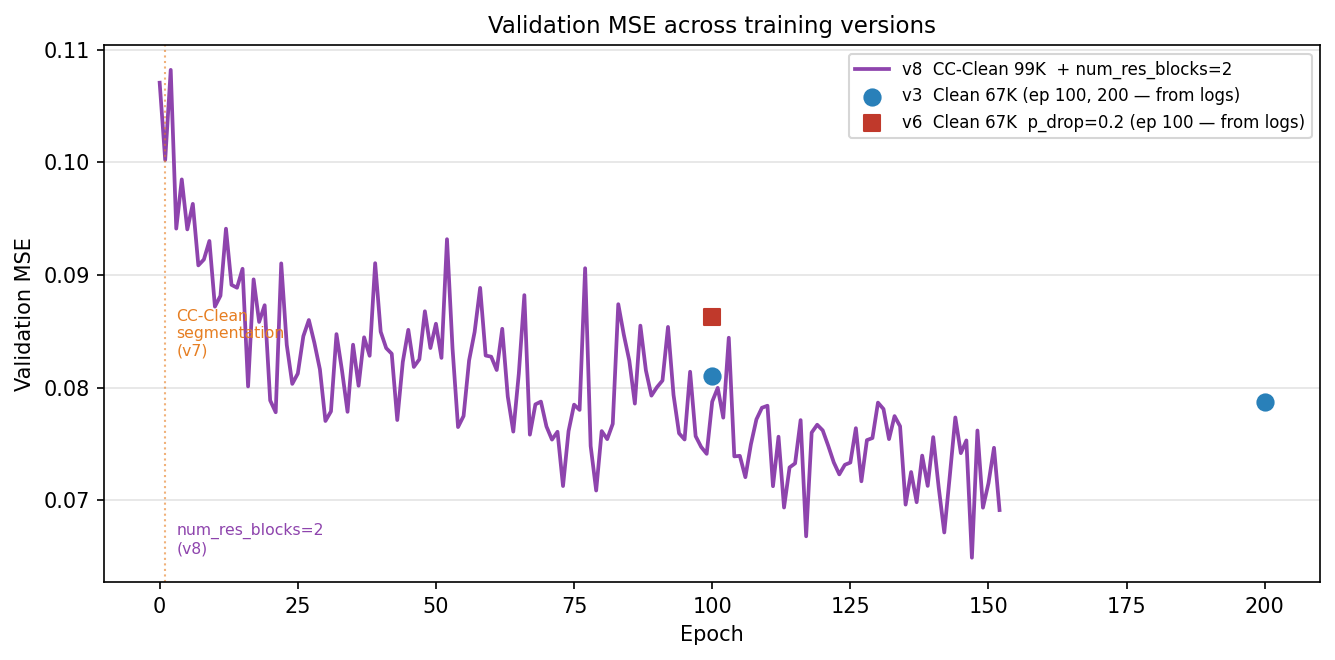

saved /home/oles/DiffusionPen/generated/thesis_figures/fig7_training_curves.pdf


In [40]:
# ── TRAINING CURVES ───────────────────────────────────────────────────────────
# Reads tensorboard scalars for v7, v8, v9. v3/v6 are hardcoded as sparse points.

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tb_scalar(tb_dir, tag='val/mse'):
    ea = EventAccumulator(tb_dir, size_guidance={'tensors': 0, 'scalars': 0})
    ea.Reload()
    available = ea.Tags().get('scalars', [])
    if tag not in available:
        print(f'  tag "{tag}" not found in {tb_dir}. Available: {available}')
        return [], []
    events = ea.Scalars(tag)
    steps  = [e.step  for e in events]
    values = [e.value for e in events]
    return steps, values

fig, ax = plt.subplots(figsize=(9, 4.5))

CURVE_STYLES = {
    'v7': dict(color='#e67e22', lw=1.8, label='v7  CC-Clean 99K'),
    'v8': dict(color='#8e44ad', lw=1.8, label='v8  CC-Clean 99K  + num_res_blocks=2'),
    'v9': dict(color='#27ae60', lw=1.8, label='v9  Extended Balanced 124K  (num_res_blocks=2)'),
}

for run_name, tb_dir in TB_DIRS.items():
    steps, vals = load_tb_scalar(tb_dir, tag='val/mse')
    if not steps:
        steps, vals = load_tb_scalar(tb_dir, tag='train/mse')
    if steps:
        kw = CURVE_STYLES.get(run_name, dict(lw=1.5, label=run_name))
        ax.plot(steps, vals, **kw)
        print(f'{run_name}: {len(steps)} points,  final={vals[-1]:.4f}')
    else:
        print(f'{run_name}: no data found')

# Sparse reference points for v3 and v6 (no local tensorboard)
ax.scatter([100, 200], [0.0810, 0.0787], color='#2980b9', s=60, zorder=5,
           label='v3  Clean 67K (ep 100, 200 — from logs)')
ax.scatter([100], [0.0863], color='#c0392b', marker='s', s=60, zorder=5,
           label='v6  Clean 67K  p_drop=0.2 (ep 100 — from logs)')

# Annotate key transitions
ax.axvline(x=1, color='#e67e22', lw=1.0, ls=':', alpha=0.6)
ax.text(3, 0.087, 'CC-Clean\nsegmentation\n(v7)', fontsize=7.5, color='#e67e22', va='top')
ax.text(3, 0.068, 'num_res_blocks=2\n(v8)', fontsize=7.5, color='#8e44ad', va='top')

ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Validation MSE', fontsize=10)
ax.set_title('Validation MSE across training versions', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.yaxis.grid(True, alpha=0.35)
ax.set_axisbelow(True)

fig.tight_layout()
out_path = os.path.join(OUT_DIR, 'fig7_training_curves.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

---
## Model Load  *(run once — required by figs 6 and 8)*

In [41]:
# ── MODEL LOAD ────────────────────────────────────────────────────────────────
# Loads v9 checkpoint + style encoder + VAE + scheduler.
# Run this once; objects are reused by figs 6 and 8.

import torch, torchvision
from types import SimpleNamespace
from diffusers import AutoencoderKL, DDIMScheduler
from transformers import CanineTokenizer, CanineModel
from generate_sentence import (
    strip_dp_prefix, detect_num_classes,
    build_writer_id_map, load_style_images,
    generate_single_word,
    align_to_baseline, normalize_ink_brightness,
    stitch_paragraph, sample_punctuation,
    split_word_for_generation, INLINE_SPLIT_CHARS,
)
from unet import UNetModel
from feature_extractor import ImageEncoder
from utils.word_dataset import char_classes as WORD_CHAR_CLASSES

device = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Checkpoint
raw_sd = torch.load(CKPT_PATH, map_location='cpu')
sd     = strip_dp_prefix(raw_sd)
num_classes = detect_num_classes(sd)
print(f'num_classes = {num_classes}')

# CANINE — required by UNetModel constructor
tokenizer    = CanineTokenizer.from_pretrained('google/canine-c')
canine_model = CanineModel.from_pretrained('google/canine-c').to(device)
canine_model.eval()

# fake_args — mirrors what generate_sentence.py passes
fake_args = SimpleNamespace(interpolation=False, mix_rate=None)

# U-Net — constructor args match generate_sentence.py exactly
unet = UNetModel(
    image_size=(IMG_H // 8, IMG_W // 8),
    in_channels=4, out_channels=4, model_channels=320,
    num_res_blocks=NUM_RES_BLOCKS,
    attention_resolutions=(1, 1),
    channel_mult=(1, 1),
    num_classes=num_classes,
    num_heads=4,
    context_dim=320,
    vocab_size=WORD_CHAR_CLASSES,
    text_encoder=canine_model,
    args=fake_args,
).to(device)
unet.load_state_dict(sd)
unet.eval()
print('U-Net loaded')

# Style encoder — same pattern as generate_sentence.py
style_extractor = ImageEncoder(model_name='mobilenetv2_100', num_classes=0,
                               pretrained=False, trainable=False).to(device)
se_sd = torch.load(STYLE_CKPT, map_location='cpu')
model_dict = style_extractor.state_dict()
se_sd = {k: v for k, v in se_sd.items()
         if k in model_dict and model_dict[k].shape == v.shape}
model_dict.update(se_sd)
style_extractor.load_state_dict(model_dict)
style_extractor.eval()
print('Style encoder loaded')

# VAE + scheduler
vae = AutoencoderKL.from_pretrained(SD_PATH, subfolder='vae').to(device)
vae.eval()
scheduler = DDIMScheduler.from_pretrained(SD_PATH, subfolder='scheduler')
print('VAE + scheduler loaded')

# Writer ID map + style references for all writers we'll use
writer_id_map = build_writer_id_map(META_BALANCED)
print(f'Total writers in map: {len(writer_id_map)}')

needed_strs = list(dict.fromkeys(SENTENCE_WRITERS + [ALIGNMENT_WRITER]))
needed_idxs = [writer_id_map[w] for w in needed_strs if w in writer_id_map]

style_refs = load_style_images(
    DATASET_ROOT, META_BALANCED, needed_idxs, writer_id_map,
    img_height=IMG_H, img_width=IMG_W,
)
print(f'Style refs loaded for {len(style_refs)} writers')
print('Model ready.')


device: cuda:0
num_classes = 323


Loading weights: 100%|██████████| 246/246 [00:00<00:00, 787.01it/s, Materializing param=projection.conv.weight]                                        
CanineModel LOAD REPORT from: google/canine-c
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


U-Net loaded
Style encoder loaded
VAE + scheduler loaded
Total writers in map: 323
Style refs loaded for 3 writers
Model ready.


---
## Fig 6 — Before/After Baseline Alignment

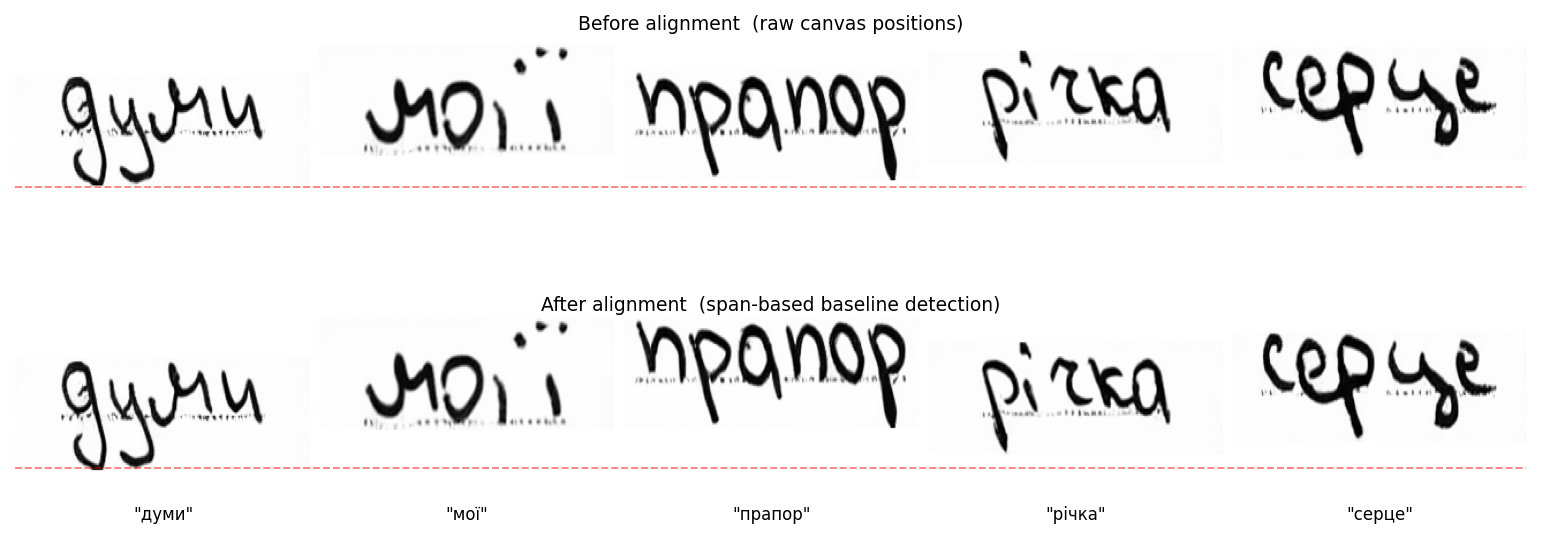

saved /home/oles/DiffusionPen/generated/thesis_figures/fig6_baseline_alignment.pdf


In [44]:
# ── BASELINE ALIGNMENT ────────────────────────────────────────────────────────
# align_to_baseline and normalize_ink_brightness both call cv2 directly,
# so they need grayscale numpy arrays, not PIL images.

writer_idx = writer_id_map[ALIGNMENT_WRITER]
style_ref  = style_refs[writer_idx]

# Generate words; convert immediately to grayscale numpy uint8
raw_imgs = []
with torch.no_grad():
    for word in ALIGNMENT_WORDS:
        img_pil = generate_single_word(
            word, unet, vae, style_extractor, tokenizer,
            scheduler, style_ref, writer_idx, device,
            cfg_scale=CFG_SCALE, img_height=IMG_H, img_width=IMG_W,
        )
        raw_imgs.append(np.array(img_pil))   # PIL 'L' → (H,W) uint8 numpy

# align_to_baseline takes numpy arrays, returns same list unchanged + shifts
aligned, shifts, _ = align_to_baseline(raw_imgs)

CANVAS_H = 104
GAP_W    = 8

def make_strip(imgs, canvas_h, gap_w, y_offsets=None):
    parts = []
    for i, img in enumerate(imgs):
        h, w = img.shape[:2]
        canvas = np.full((canvas_h, w), 255, dtype=np.uint8)
        off = int(y_offsets[i]) if y_offsets is not None else 0
        off = max(0, min(off, canvas_h - h))
        canvas[off:off+h, :] = img
        if parts:
            parts.append(np.full((canvas_h, gap_w), 255, dtype=np.uint8))
        parts.append(canvas)
    return np.concatenate(parts, axis=1)

# Raw strip — artificial random offsets to illustrate the misalignment problem
rng_offs  = [random.randint(0, 30) for _ in raw_imgs]
strip_raw = make_strip(raw_imgs, CANVAS_H, GAP_W, y_offsets=rng_offs)

# Aligned strip — shifts from align_to_baseline
strip_aln = make_strip(aligned, CANVAS_H, GAP_W, y_offsets=shifts)

fig, axes = plt.subplots(2, 1, figsize=(13, 4), gridspec_kw={'hspace': 0.55})

for ax_row, strip, title in [
    (axes[0], strip_raw, 'Before alignment  (raw canvas positions)'),
    (axes[1], strip_aln, 'After alignment  (span-based baseline detection)'),
]:
    ax_row.imshow(strip, cmap='gray', aspect='auto', vmin=0, vmax=255)
    ax_row.set_title(title, fontsize=9, pad=3)
    ax_row.axhline(y=CANVAS_H - 18, color='red', lw=0.9, ls='--', alpha=0.5)
    ax_row.axis('off')

x_cursor = 0
for img, word in zip(aligned, ALIGNMENT_WORDS):
    cw = img.shape[1]
    axes[1].text(x_cursor + cw/2, CANVAS_H + 4, f'"{word}"',
                 ha='center', va='top', fontsize=8)
    x_cursor += cw + GAP_W

out_path = os.path.join(OUT_DIR, 'fig6_baseline_alignment.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)


---
## Fig 8 — Sentence Output Strips

Generating: writer=0004  "думи мої думи"
Generating: writer=0004  "жовто-блакитний прапор"
Generating: writer=0050  "думи мої думи"
Generating: writer=0050  "жовто-блакитний прапор"
Generating: writer=0120  "думи мої думи"
Generating: writer=0120  "жовто-блакитний прапор"


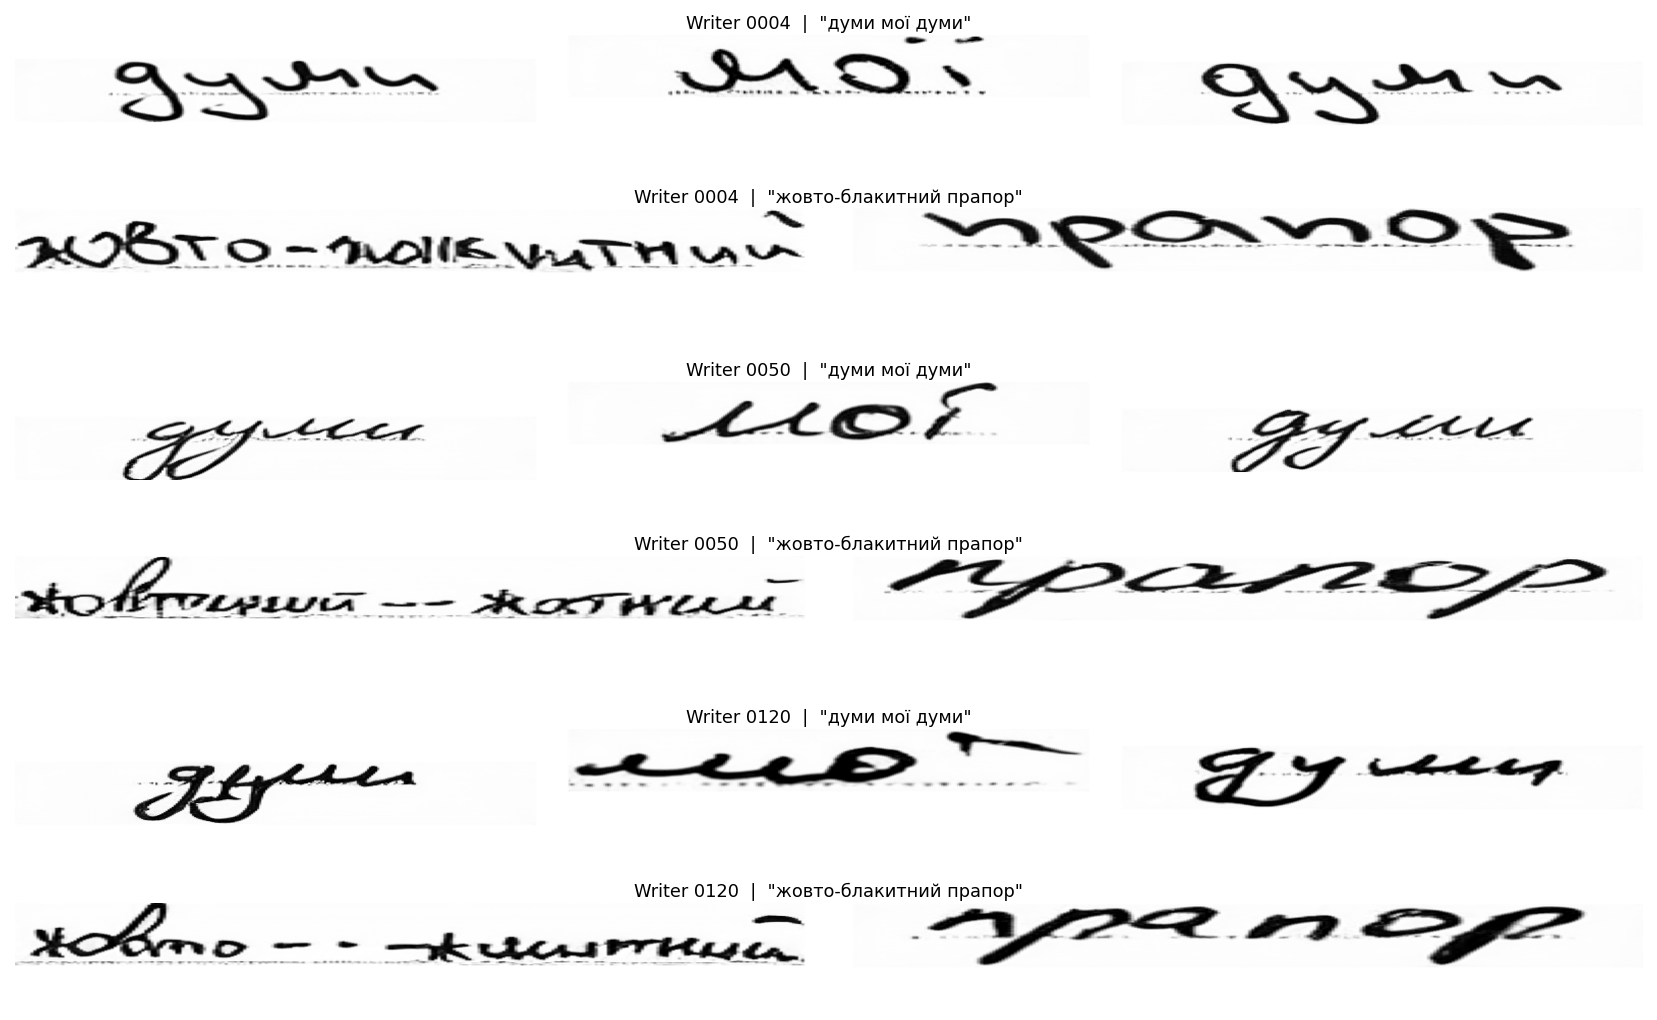

saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_sentence_strips.pdf
  saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_w0004_думи_мої_думи.png
  saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_w0004_жовтоHYPHENблакитний_прапор.png
  saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_w0050_думи_мої_думи.png
  saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_w0050_жовтоHYPHENблакитний_прапор.png
  saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_w0120_думи_мої_думи.png
  saved /home/oles/DiffusionPen/generated/thesis_figures/fig8_w0120_жовтоHYPHENблакитний_прапор.png


In [45]:
# ── SENTENCE STRIPS ───────────────────────────────────────────────────────────
# Change SENTENCE_WRITERS / SENTENCE_TEXT in the config cell to try different
# combinations without re-running the model load.

CANVAS_H = 104
GAP_W    = 16

sentences = [SENTENCE_TEXT, SENTENCE_TEXT_HYPHENATED]

def generate_sentence_strip(text, writer_str, canvas_h=CANVAS_H, gap_w=GAP_W):
    widx = writer_id_map[writer_str]
    sref = style_refs[widx]

    word_imgs, is_punct_flags = [], []
    with torch.no_grad():
        for word in text.split():
            parts = split_word_for_generation(word, punct_bank=None, img_height=IMG_H)
            for part, is_p in parts:
                if is_p:
                    arr = sample_punctuation(part, IMG_H)  # already numpy
                    word_imgs.append(arr)
                else:
                    img_pil = generate_single_word(
                        part, unet, vae, style_extractor, tokenizer,
                        scheduler, sref, widx, device,
                        cfg_scale=CFG_SCALE, img_height=IMG_H, img_width=IMG_W,
                    )
                    word_imgs.append(np.array(img_pil))   # PIL 'L' → numpy
                is_punct_flags.append(is_p)

    aligned, shifts, _ = align_to_baseline(word_imgs, is_punct=is_punct_flags)
    word_imgs = normalize_ink_brightness(aligned)

    parts = []
    for img, shift in zip(word_imgs, shifts):
        h, w = img.shape[:2]
        canvas = np.full((canvas_h, w), 255, dtype=np.uint8)
        off = max(0, min(int(shift), canvas_h - h))
        canvas[off:off+h, :] = img
        if parts:
            parts.append(np.full((canvas_h, gap_w), 255, dtype=np.uint8))
        parts.append(canvas)
    return np.concatenate(parts, axis=1)

strips = {}
for wstr in SENTENCE_WRITERS:
    for sent in sentences:
        print(f'Generating: writer={wstr}  "{sent}"')
        strips[(wstr, sent)] = generate_sentence_strip(sent, wstr)

n_rows = len(SENTENCE_WRITERS) * len(sentences)
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 1.4 * n_rows),
                          gridspec_kw={'hspace': 0.7})
if n_rows == 1:
    axes = [axes]

row_idx = 0
for wstr in SENTENCE_WRITERS:
    for sent in sentences:
        strip = strips[(wstr, sent)]
        ax = axes[row_idx]
        ax.imshow(strip, cmap='gray', aspect='auto', vmin=0, vmax=255)
        ax.set_title(f'Writer {wstr}  |  "{sent}"', fontsize=8.5, pad=3)
        ax.axis('off')
        row_idx += 1

out_path = os.path.join(OUT_DIR, 'fig8_sentence_strips.pdf')
fig.savefig(out_path)
fig.savefig(out_path.replace('.pdf', '.png'))
plt.show()
print('saved', out_path)

for (wstr, sent), strip in strips.items():
    safe = sent.replace(' ', '_').replace('-', 'HYPHEN')[:30]
    p = os.path.join(OUT_DIR, f'fig8_w{wstr}_{safe}.png')
    Image.fromarray(strip).save(p)
    print('  saved', p)
